<a href="https://colab.research.google.com/github/najwasuparna/DiabeticFootUlcer-Detection/blob/main/DFU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MOUNT GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


INSTALL LIBRARY

In [ ]:
!pip install ultralytics -q
!pip install torch torchvision -q
!pip install pandas openpyxl matplotlib scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.6 MB/s eta 0:00:00


IMPORT & PATH

In [ ]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

BASE = "/content/drive/MyDrive/otb_code/projectOTB"
YOLO_PATH = f"{BASE}/FootUlcer"

RESULT = f"{BASE}/result"
os.makedirs(RESULT, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv8s


DATA YAML

In [ ]:
data_yaml = f"{YOLO_PATH}/data.yaml"

with open(data_yaml, "w") as f:
    f.write(f"""
path: {YOLO_PATH}
train: train/images
val: valid/images
test: test/images

names:
  0: ulcer
""")

LOAD MODEL

In [ ]:
model = YOLO("yolov8s.pt")

TRAIN

In [ ]:
model.train(
    data=data_yaml,
    epochs=100,
    imgsz=512,
    batch=8,              # lebih aman untuk Colab
    lr0=0.0005,           # sedikit lebih kecil
    optimizer="AdamW",
    weight_decay=0.0005,
    patience=15,

    augment=True,
    degrees=5,            # jangan terlalu banyak rotasi
    fliplr=0.5,
    mosaic=0.3,
    mixup=0.0,            # OFF

    project=RESULT,
    name="YOLOv8_DFU"
)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/otb_code/projectOTB/FootUlcer/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=YOLOv8_DFU-10, nbs=64, nms=False, opset=None, optimize=False, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aa27d457530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

VALIDATION

In [ ]:
metrics_yolo = model.val(
    data=data_yaml,
    split="test"
)
map50_yolo = metrics_yolo.box.map50
map5095_yolo = metrics_yolo.box.map

precision_yolo = metrics_yolo.box.mp
recall_yolo = metrics_yolo.box.mr

print("YOLO RESULTS")
print("mAP@50:", map50_yolo)
print("mAP@50:95:", map5095_yolo)
print("Precision:", precision_yolo)
print("Recall:", recall_yolo)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.9±0.4 ms, read: 12.7±0.8 MB/s, size: 22.6 KB)
val: Scanning /content/drive/MyDrive/otb_code/projectOTB/FootUlcer/test/labels.cache... 98 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 98/98 29.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.7it/s 2.5s
                   all         98        107      0.941      0.907      0.948      0.572
Speed: 4.4ms preprocess, 6.7ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val-2
YOLO RESULTS
mAP@50: 0.9483563700847815
mAP@50:95: 0.5723127483587107
Precision: 0.9407586826352096
Recall: 0.9065420560747663


TEST

In [ ]:
model.predict(
    source=f"{YOLO_PATH}/test/images",
    save=True,
    conf=0.25
)


image 1/98 /content/drive/MyDrive/otb_code/projectOTB/FootUlcer/test/images/1011_png.rf.ed560178b9906735d6d56fe5d009768f.jpg: 512x512 2 ulcers, 11.1ms
image 2/98 /content/drive/MyDrive/otb_code/projectOTB/FootUlcer/test/images/1016_png.rf.1273969a3649b78893cc010f85c96480.jpg: 512x512 2 ulcers, 11.0ms
image 3/98 /content/drive/MyDrive/otb_code/projectOTB/FootUlcer/test/images/1018_png.rf.949c8ac8f4f08c528825e5bfa1c30539.jpg: 512x512 1 ulcer, 11.8ms
image 4/98 /content/drive/MyDrive/otb_code/projectOTB/FootUlcer/test/images/1020_png.rf.0b240701e603ed5d8a140c488ec17c0c.jpg: 512x512 1 ulcer, 11.1ms
image 5/98 /content/drive/MyDrive/otb_code/projectOTB/FootUlcer/test/images/1021_png.rf.66108c4e17a4be063f1eda684f296b6c.jpg: 512x512 1 ulcer, 11.1ms
image 6/98 /content/drive/MyDrive/otb_code/projectOTB/FootUlcer/test/images/1022_png.rf.a1764d057510e6401dc880c8298384a1.jpg: 512x512 1 ulcer, 11.2ms
image 7/98 /content/drive/MyDrive/otb_code/projectOTB/FootUlcer/test/images/1024_png.rf.dff62f9a9

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'ulcer'}
 obb: None
 orig_img: array([[[159, 155, 160],
         [157, 153, 158],
         [153, 149, 154],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[164, 160, 165],
         [162, 158, 163],
         [157, 153, 158],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[171, 167, 172],
         [169, 165, 170],
         [164, 160, 165],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        ...,
 
        [[ 25,  27,  28],
         [ 25,  27,  28],
         [ 25,  27,  28],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[ 25,  27,  28],
         [ 25,  27,  28],
         [ 25,  27,  28],
         ...,
         [  0,   0,

Function IoU

In [ ]:
import os
import glob

def yolo_to_xyxy(box):
    x, y, w, h = box
    x1 = x - w/2
    y1 = y - h/2
    x2 = x + w/2
    y2 = y + h/2
    return [x1, y1, x2, y2]

def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    if union == 0:
        return 0
    return inter / union

Baca ground truth label

In [ ]:
def load_gt(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        vals = list(map(float, line.strip().split()))
        cls, x, y, w, h = vals
        boxes.append(yolo_to_xyxy([x, y, w, h]))

    return boxes

Evaluasi YOLO

In [ ]:
test_images = glob.glob(f"{YOLO_PATH}/test/images/*")

TP = 0
FP = 0
FN = 0
TN = 0

IOU_THRESHOLD = 0.3
CONF = 0.25

for img_path in test_images:
    label_path = img_path.replace("/images/", "/labels/")
    label_path = os.path.splitext(label_path)[0] + ".txt"

    gt_boxes = load_gt(label_path)

    results = model.predict(img_path, conf=CONF, verbose=False)

    pred_boxes = []
    for box in results[0].boxes.xywhn.cpu().numpy():
      pred_boxes.append(yolo_to_xyxy(box))

      print("GT:", gt_boxes[:2])
      print("Pred:", pred_boxes[:2])
      break

    matched = set()

    # Cocokkan prediction dengan GT
    for pred in pred_boxes:
        best_iou = 0
        best_idx = -1

        for i, gt in enumerate(gt_boxes):
            if i in matched:
                continue

            iou = compute_iou(pred, gt)

            if iou > best_iou:
                best_iou = iou
                best_idx = i

        if best_iou >= IOU_THRESHOLD:
            TP += 1
            matched.add(best_idx)
        else:
            FP += 1

    FN += len(gt_boxes) - len(matched)

    if len(gt_boxes) == 0 and len(pred_boxes) == 0:
        TN += 1

GT: [[0.2763671875, 0.38330078125, 0.3798828125, 0.45654296875]]
Pred: [[np.float32(0.27456552), np.float32(0.38040102), np.float32(0.38126463), np.float32(0.45317566)]]
GT: [[0.2998046875, 0.25146484375, 0.3857421875, 0.34033203125]]
Pred: [[np.float32(0.29830128), np.float32(0.24989986), np.float32(0.38631207), np.float32(0.33894408)]]
GT: [[0.359375, 0.23095703125, 0.39453125, 0.28076171875]]
Pred: [[np.float32(0.35520378), np.float32(0.22583622), np.float32(0.39523128), np.float32(0.28100348)]]
GT: [[0.39111328125, 0.4384765625, 0.46240234375, 0.5830078125]]
Pred: [[np.float32(0.3799504), np.float32(0.43002903), np.float32(0.49190646), np.float32(0.5762583)]]
GT: [[0.33056640625, 0.43994140625, 0.46435546875, 0.59130859375]]
Pred: [[np.float32(0.31888455), np.float32(0.4352035), np.float32(0.47682875), np.float32(0.5954458)]]
GT: [[0.3984375, 0.42578125, 0.45703125, 0.48046875]]
Pred: [[np.float32(0.39295632), np.float32(0.42191637), np.float32(0.4573763), np.float32(0.4813003)]]
G

Hitung metrics

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-16)
precision = TP / (TP + FP + 1e-16)
recall = TP / (TP + FN + 1e-16)
f1 = 2 * precision * recall / (precision + recall + 1e-16)

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")
print()
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1: {f1:.3f}")

TP: 97
FP: 1
FN: 10
TN: 0

Accuracy: 0.898
Precision: 0.990
Recall: 0.907
F1: 0.946


In [ ]:
# Simpan metric YOLO ke variabel khusus
yolo_accuracy = accuracy
yolo_precision = precision
yolo_recall = recall
yolo_f1 = f1

# Ambil mAP dari Ultralytics
yolo_map50 = metrics_yolo.box.map50
yolo_map = metrics_yolo.box.map

print(f"mAP@50: {yolo_map50:.3f}")
print(f"mAP@50:95: {yolo_map:.3f}")

mAP@50: 0.948
mAP@50:95: 0.572


SSD

Install:

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.5 MB/s eta 0:00:00


Import

In [ ]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F
from torchvision.models.detection import ssd300_vgg16
from torchmetrics.detection.mean_ap import MeanAveragePrecision

Dataset

In [ ]:
class DFUDataset(Dataset):
    def __init__(self, img_dir, ann_file):
        self.img_dir = img_dir

        with open(ann_file) as f:
            coco = json.load(f)

        self.images = coco["images"]
        self.annotations = coco["annotations"]

        self.ann_map = {}
        for ann in self.annotations:
            img_id = ann["image_id"]
            if img_id not in self.ann_map:
                self.ann_map[img_id] = []
            self.ann_map[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]

        path = os.path.join(self.img_dir, img_info["file_name"])
        image = Image.open(path).convert("RGB")
        image = F.to_tensor(image)

        boxes = []
        labels = []

        anns = self.ann_map.get(img_info["id"], [])

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x+w, y+h])
            labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target

DataLoader

In [ ]:
base = "/content/drive/MyDrive/otb_code/projectOTB/dataset_ssd"

train_dataset = DFUDataset(
    f"{base}/train",
    f"{base}/train/_annotations.coco.json"
)

valid_dataset = DFUDataset(
    f"{base}/valid",
    f"{base}/valid/_annotations.coco.json"
)

test_dataset = DFUDataset(
    f"{base}/test",
    f"{base}/test/_annotations.coco.json"
)

Collate function:

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

Loader:

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

Model SSD

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_ssd = ssd300_vgg16(weights="DEFAULT")
model_ssd.head.classification_head.num_classes = 2
model_ssd.to(device)

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:02<00:00, 54.9MB/s]


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

Optimizer

In [ ]:
optimizer = torch.optim.Adam(model_ssd.parameters(), lr=0.0001)

Training

In [ ]:
num_epochs = 100

for epoch in range(num_epochs):
    model_ssd.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model_ssd(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

Epoch 1/100, Loss: 43.8186
Epoch 2/100, Loss: 43.7575
Epoch 3/100, Loss: 40.0955
Epoch 4/100, Loss: 103.4808
Epoch 5/100, Loss: 68.8112
Epoch 6/100, Loss: 32.2800
Epoch 7/100, Loss: 26.5222
Epoch 8/100, Loss: 16.8178
Epoch 9/100, Loss: 17.1951
Epoch 10/100, Loss: 23.1231
Epoch 11/100, Loss: 25.1115
Epoch 12/100, Loss: 16.0838
Epoch 13/100, Loss: 12.6317
Epoch 14/100, Loss: 11.4315
Epoch 15/100, Loss: 13.0554
Epoch 16/100, Loss: 14.2351
Epoch 17/100, Loss: 21.4821
Epoch 18/100, Loss: 56.6949
Epoch 19/100, Loss: 79.7146
Epoch 20/100, Loss: 46.7664
Epoch 21/100, Loss: 26.5790
Epoch 22/100, Loss: 20.5663
Epoch 23/100, Loss: 18.5630
Epoch 24/100, Loss: 10.4323
Epoch 25/100, Loss: 8.0919
Epoch 26/100, Loss: 9.1325
Epoch 27/100, Loss: 20.9772
Epoch 28/100, Loss: 127.0078
Epoch 29/100, Loss: 108.2720
Epoch 30/100, Loss: 26.4876
Epoch 31/100, Loss: 15.3688
Epoch 32/100, Loss: 13.2086
Epoch 33/100, Loss: 6.5808
Epoch 34/100, Loss: 5.1518
Epoch 35/100, Loss: 4.4801
Epoch 36/100, Loss: 3.7919
Epoc

evaluator:

In [ ]:
def evaluate_map_ssd(model, loader, device):
    metric = MeanAveragePrecision()
    model.eval()

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            preds = []
            gts = []

            for output, target in zip(outputs, targets):
                preds.append({
                    "boxes": output["boxes"].cpu(),
                    "scores": output["scores"].cpu(),
                    "labels": output["labels"].cpu()
                })

                gts.append({
                    "boxes": target["boxes"].cpu(),
                    "labels": target["labels"].cpu()
                })

            metric.update(preds, gts)

    result = metric.compute()
    return result

Fungsi IoU

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - inter_area

    if union == 0:
        return 0

    return inter_area / union

Evaluasi SSD dengan IoU

In [ ]:
def evaluate_iou(model, loader, device, score_threshold=0.3, iou_threshold=0.5):
    TP = 0
    FP = 0
    FN = 0

    model.eval()

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for pred, target in zip(outputs, targets):

                pred_boxes = pred["boxes"].cpu().numpy()
                pred_scores = pred["scores"].cpu().numpy()
                gt_boxes = target["boxes"].cpu().numpy()

                # filter prediksi berdasarkan confidence
                keep = pred_scores > score_threshold
                pred_boxes = pred_boxes[keep]

                matched_gt = set()

                for pb in pred_boxes:
                    best_iou = 0
                    best_gt_idx = -1

                    for i, gb in enumerate(gt_boxes):
                        if i in matched_gt:
                            continue

                        iou = compute_iou(pb, gb)

                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = i

                    if best_iou >= iou_threshold:
                        TP += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        FP += 1

                FN += len(gt_boxes) - len(matched_gt)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    accuracy = TP / (TP + FP + FN + 1e-6)

    print("SSD RESULT (IoU Based)")
    print("TP:", TP)
    print("FP:", FP)
    print("FN:", FN)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

    return accuracy, precision, recall, f1

Jalankan

In [ ]:
ssd_accuracy, ssd_precision, ssd_recall, ssd_f1 = evaluate_iou(
    model_ssd, test_loader, device
)

ssd_map_result = evaluate_map_ssd(model_ssd, test_loader, device)
print(ssd_map_result)

ssd_map50 = ssd_map_result["map_50"].item()
ssd_map = ssd_map_result["map"].item()

SSD RESULT (IoU Based)
TP: 101
FP: 9
FN: 6
Accuracy: 0.8706896476664686
Precision: 0.9181818098347109
Recall: 0.9439252248231288
F1: 0.9308750675532004
{'map': tensor(0.5282), 'map_50': tensor(0.9286), 'map_75': tensor(0.5601), 'map_small': tensor(0.4326), 'map_medium': tensor(0.5653), 'map_large': tensor(-1.), 'mar_1': tensor(0.5589), 'mar_10': tensor(0.5963), 'mar_100': tensor(0.5963), 'mar_small': tensor(0.4643), 'mar_medium': tensor(0.6430), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}


tabel

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "mAP@50", "mAP@50:95"],

    "YOLOv8s": [
        accuracy,                     # dari YOLO
        precision,
        recall,
        f1,
        metrics_yolo.box.map50,
        metrics_yolo.box.map
    ],

    "SSD": [
        ssd_accuracy,
        ssd_precision,
        ssd_recall,
        ssd_f1,
        ssd_map50,
        ssd_map
    ]
})

display(comparison_df)

,Metric,YOLOv8s,SSD
0,Accuracy,0.898148,0.870690
1,Precision,0.989796,0.918182
2,Recall,0.906542,0.943925
3,F1-Score,0.946341,0.930875
4,mAP@50,0.948356,0.928557
5,mAP@50:95,0.572313,0.528221


Diagram batang

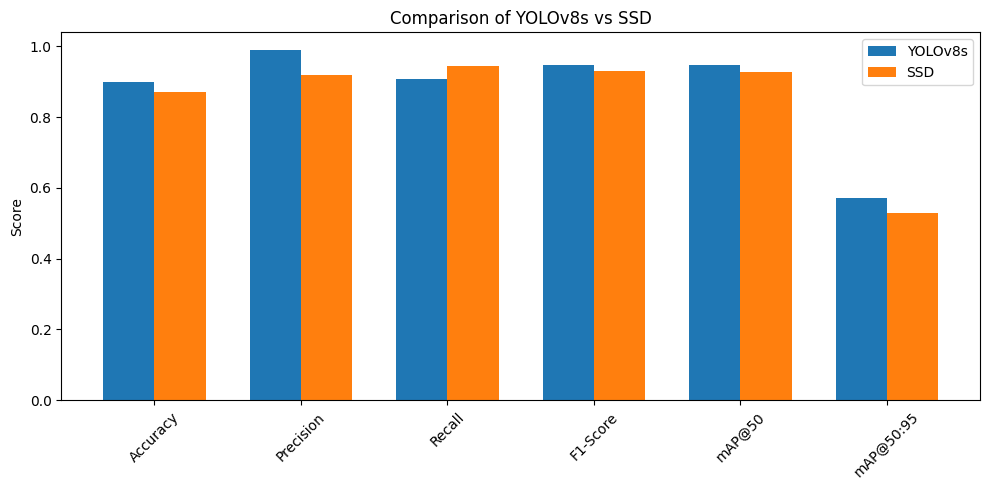

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = comparison_df["Metric"]
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, comparison_df["YOLOv8s"], width, label="YOLOv8s")
plt.bar(x + width/2, comparison_df["SSD"], width, label="SSD")

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Comparison of YOLOv8s vs SSD")
plt.legend()
plt.tight_layout()
plt.show()

=== TABEL PERBANDINGAN MODEL ===


,Metric,YOLOv8s,SSD
0,Accuracy,0.898,0.871
1,Precision,0.990,0.918
2,Recall,0.907,0.944
3,F1-Score,0.946,0.931
4,mAP@50,0.948,0.929
5,mAP@50:95,0.572,0.528


Tabel berhasil disimpan ke: /content/drive/MyDrive/otb_code/projectOTB/result/comparison_metrics.xlsx


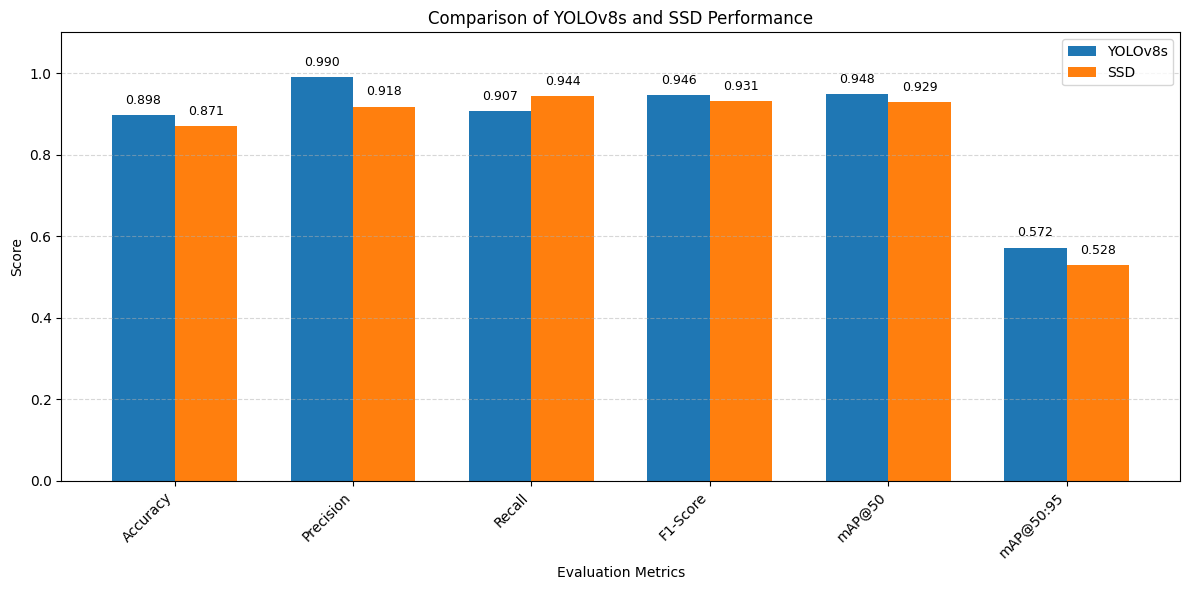

Diagram berhasil disimpan ke: /content/drive/MyDrive/otb_code/projectOTB/result/comparison_chart.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# RAPIIKAN TABEL
# =========================
comparison_df = comparison_df.round(3)

print("=== TABEL PERBANDINGAN MODEL ===")
display(comparison_df)

# =========================
# SIMPAN KE EXCEL
# =========================
excel_path = "/content/drive/MyDrive/otb_code/projectOTB/result/comparison_metrics.xlsx"
comparison_df.to_excel(excel_path, index=False)

print(f"Tabel berhasil disimpan ke: {excel_path}")

# =========================
# DIAGRAM BATANG
# =========================
metrics = comparison_df["Metric"]
yolo_scores = comparison_df["YOLOv8s"]
ssd_scores = comparison_df["SSD"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12,6))

bars1 = plt.bar(
    x - width/2,
    yolo_scores,
    width,
    label="YOLOv8s"
)

bars2 = plt.bar(
    x + width/2,
    ssd_scores,
    width,
    label="SSD"
)

plt.xticks(x, metrics, rotation=45, ha='right')
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Comparison of YOLOv8s and SSD Performance")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tambahkan angka di atas batang
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()

# =========================
# SIMPAN GAMBAR
# =========================
chart_path = "/content/drive/MyDrive/otb_code/projectOTB/result/comparison_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Diagram berhasil disimpan ke: {chart_path}")